# Projekt 6 — NCG jako solver regresji logistycznej

## Część podstawowa

W tej części projektu rozwiązujemy problem regresji logistycznej dla zbioru `breast_cancer`.

Implementujemy:
- funkcję straty logistycznej,
- gradient funkcji straty,
- hesjan funkcji straty,
- Gradient Descent ze stałym krokiem,
- metodę NCG-PRP+ z warunkiem Armijo,
- metodę Newtona-Raphsona z backtracking line search.

Dla każdej metody zapisujemy:
- liczbę iteracji,
- czas działania,
- końcową wartość funkcji straty,
- accuracy na zbiorze testowym.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

załadowanie i przygotowanie danych

In [2]:
# Zaladowanie gotowego zbioru breast_cancer z biblioteki sklearn
data = load_breast_cancer()

# X zawiera cechy opisujace obserwacje
# y zawiera etykiety klas, ktore model ma przewidywac
X = data.data
y = data.target

# Wypisujemy podstawowe informacje o zbiorze danych
print("Liczba obserwacji:", X.shape[0])
print("Liczba cech:", X.shape[1])
print("Etykiety:", np.unique(y))

Liczba obserwacji: 569
Liczba cech: 30
Etykiety: [0 1]


In [3]:
# Zamieniamy etykiety z {0, 1} na {-1, 1}
# Jest to wygodne dla zapisu funkcji straty logistycznej:
# log(1 + exp(-y_i * x_i^T w))

y = 2 * y - 1

print("Etykiety po zamianie:", np.unique(y))

Etykiety po zamianie: [-1  1]


In [4]:
# Podzial na zbior treningowy i testowy

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (455, 30)
X_test: (114, 30)


In [5]:
# Standaryzacja danych
# Metody gradientowe sa wrazliwe na skale zmiennych,
# dlatego standaryzujemy cechy do sredniej 0 i odchylenia 1.

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# Dodajemy kolumne jedynek, aby model mial wyraz wolny.
# Wtedy wektor w zawiera zarowno wspolczynniki przy cechach, jak i bias.

X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

print("X_train po dodaniu wyrazu wolnego:", X_train.shape)
print("X_test po dodaniu wyrazu wolnego:", X_test.shape)

X_train po dodaniu wyrazu wolnego: (455, 31)
X_test po dodaniu wyrazu wolnego: (114, 31)


funkcja straty logistycznej

In [7]:
def logistic_loss(w, X, y):
    """
    Funkcja straty logistycznej:

        l(w) = 1/m * sum log(1 + exp(-y_i * x_i^T w))

    gdzie:
    X - macierz danych,
    y - etykiety z {-1, 1},
    w - wektor parametrow.
    """
    z = y * (X @ w)

    return np.mean(np.logaddexp(0, -z))

Tu używamy np.logaddexp(0, -z), bo to jest stabilniejsze numerycznie

gradient

In [8]:
def logistic_gradient(w, X, y):
    """
    Gradient funkcji straty logistycznej.

    Dla l(w) = 1/m * sum log(1 + exp(-y_i * x_i^T w))
    gradient ma postac:

        grad l(w) = -1/m * X^T (y * s)

    gdzie:
        s_i = 1 / (1 + exp(y_i * x_i^T w))
    """
    m = X.shape[0]
    z = y * (X @ w)

    # Zabezpieczenie numeryczne przed bardzo duzymi wartosciami w exp
    z = np.clip(z, -500, 500)

    s = 1.0 / (1.0 + np.exp(z))

    grad = -(X.T @ (y * s)) / m

    return grad

## Hesjan funkcji straty

In [9]:
def logistic_hessian(w, X, y):
    """
    Hesjan funkcji straty logistycznej.

    H = 1/m * X^T D X

    gdzie D jest macierza diagonalna z elementami:
        s_i * (1 - s_i)

    W kodzie nie tworzymy jawnie calej macierzy D,
    tylko mnozymy kazdy wiersz X przez odpowiednia wage.
    """
    m = X.shape[0]
    z = y * (X @ w)
    z = np.clip(z, -500, 500)

    s = 1.0 / (1.0 + np.exp(z))
    weights = s * (1.0 - s)

    H = (X.T @ (X * weights[:, np.newaxis])) / m

    return H

predykcja i accuracy

In [10]:
def predict_labels(w, X):
    """
    Predykcja etykiet {-1, 1}.
    """
    scores = X @ w
    y_pred = np.where(scores >= 0, 1, -1)

    return y_pred


def accuracy(w, X, y):
    """
    Accuracy modelu dla danych X, y.
    """
    y_pred = predict_labels(w, X)
    return accuracy_score(y, y_pred)

szybki test funkcji

In [11]:
# Testujemy, czy funkcje zwracaja poprawne rozmiary

n = X_train.shape[1]
w0 = np.zeros(n)

loss0 = logistic_loss(w0, X_train, y_train)
grad0 = logistic_gradient(w0, X_train, y_train)
H0 = logistic_hessian(w0, X_train, y_train)

print("Wartosc funkcji w punkcie startowym:", loss0)
print("Rozmiar gradientu:", grad0.shape)
print("Rozmiar hesjanu:", H0.shape)
print("Norma gradientu:", np.linalg.norm(grad0))

Wartosc funkcji w punkcie startowym: 0.6931471805599453
Rozmiar gradientu: (31,)
Rozmiar hesjanu: (31, 31)
Norma gradientu: 1.430521139438935


Bo dla zerowych wag regresja logistyczna daje stratę około log(2).

In [12]:
# Prosta walidacja: po malym kroku w kierunku przeciwnym do gradientu
# wartosc funkcji celu powinna sie zmniejszyc.

alpha_test = 0.01

w1 = w0 - alpha_test * grad0

loss1 = logistic_loss(w1, X_train, y_train)

print("Strata przed krokiem:", loss0)
print("Strata po kroku gradientowym:", loss1)
print("Czy strata spadla?", loss1 < loss0)

Strata przed krokiem: 0.6931471805599453
Strata po kroku gradientowym: 0.6730135391815402
Czy strata spadla? True


Gradient Descent ze stałym krokiem

In [13]:
def gradient_descent(X, y, alpha=0.1, max_iter=1000, tol=1e-6):
    """
    Gradient Descent ze stalym krokiem.

    Iteracja:
        w_{k+1} = w_k - alpha * grad l(w_k)
    """
    n = X.shape[1]
    w = np.zeros(n)

    loss_hist = []
    grad_norm_hist = []

    start_time = time.time()

    for k in range(max_iter):
        loss_value = logistic_loss(w, X, y)
        grad = logistic_gradient(w, X, y)
        grad_norm = np.linalg.norm(grad)

        loss_hist.append(loss_value)
        grad_norm_hist.append(grad_norm)

        if grad_norm < tol:
            break

        w = w - alpha * grad

    end_time = time.time()

    result = {
        "w": w,
        "loss_hist": np.array(loss_hist),
        "grad_norm_hist": np.array(grad_norm_hist),
        "iterations": k + 1,
        "time": end_time - start_time,
        "final_loss": logistic_loss(w, X, y),
        "converged": grad_norm < tol
    }

    return result

Armijo backtracking

In [14]:
def armijo_backtracking(w, d, X, y, alpha0=1.0, c=1e-4, rho=0.5):
    """
    Backtracking line search z warunkiem Armijo.

    Szukamy alpha takiego, ze:

        l(w + alpha d) <= l(w) + c * alpha * grad^T d

    Parametry:
    alpha0 - poczatkowa dlugosc kroku,
    c - stala Armijo,
    rho - wspolczynnik zmniejszania kroku.
    """
    alpha = alpha0

    loss_w = logistic_loss(w, X, y)
    grad = logistic_gradient(w, X, y)

    while logistic_loss(w + alpha * d, X, y) > loss_w + c * alpha * (grad @ d):
        alpha = rho * alpha

        if alpha < 1e-12:
            break

    return alpha

NCG-PRP+

In [15]:
def ncg_prp_plus(X, y, max_iter=1000, tol=1e-6):
    """
    Nieliniowa metoda gradientow sprzezonych PRP+.

    beta_PRP = g_k^T (g_k - g_{k-1}) / (g_{k-1}^T g_{k-1})
    beta_PRP+ = max(0, beta_PRP)

    Kierunek:
        d_k = -g_k + beta_k d_{k-1}
    """
    n = X.shape[1]
    w = np.zeros(n)

    g = logistic_gradient(w, X, y)
    d = -g

    loss_hist = []
    grad_norm_hist = []

    start_time = time.time()

    for k in range(max_iter):
        loss_value = logistic_loss(w, X, y)
        grad_norm = np.linalg.norm(g)

        loss_hist.append(loss_value)
        grad_norm_hist.append(grad_norm)

        if grad_norm < tol:
            break

        alpha = armijo_backtracking(w, d, X, y)

        w_new = w + alpha * d
        g_new = logistic_gradient(w_new, X, y)

        numerator = g_new @ (g_new - g)
        denominator = g @ g

        if denominator == 0:
            beta = 0
        else:
            beta = numerator / denominator

        beta = max(0, beta)

        d_new = -g_new + beta * d

        # Zabezpieczenie: jesli kierunek nie jest spadkowy, robimy restart
        if g_new @ d_new >= 0:
            d_new = -g_new

        w = w_new
        g = g_new
        d = d_new

    end_time = time.time()

    result = {
        "w": w,
        "loss_hist": np.array(loss_hist),
        "grad_norm_hist": np.array(grad_norm_hist),
        "iterations": k + 1,
        "time": end_time - start_time,
        "final_loss": logistic_loss(w, X, y),
        "converged": grad_norm < tol
    }

    return result

Newton-Raphson

In [16]:
def newton_raphson(X, y, max_iter=100, tol=1e-6, reg=1e-6):
    """
    Metoda Newtona-Raphsona z backtracking line search.

    Kierunek Newtona:
        H d = -g

    Nie liczymy jawnie odwrotnosci H,
    tylko rozwiazujemy uklad rownan liniowych.
    """
    n = X.shape[1]
    w = np.zeros(n)

    loss_hist = []
    grad_norm_hist = []

    start_time = time.time()

    for k in range(max_iter):
        loss_value = logistic_loss(w, X, y)
        grad = logistic_gradient(w, X, y)
        H = logistic_hessian(w, X, y)

        grad_norm = np.linalg.norm(grad)

        loss_hist.append(loss_value)
        grad_norm_hist.append(grad_norm)

        if grad_norm < tol:
            break

        # Mala regularyzacja numeryczna, zeby uklad byl stabilniejszy
        H_reg = H + reg * np.eye(n)

        d = np.linalg.solve(H_reg, -grad)

        alpha = armijo_backtracking(w, d, X, y)

        w = w + alpha * d

    end_time = time.time()

    result = {
        "w": w,
        "loss_hist": np.array(loss_hist),
        "grad_norm_hist": np.array(grad_norm_hist),
        "iterations": k + 1,
        "time": end_time - start_time,
        "final_loss": logistic_loss(w, X, y),
        "converged": grad_norm < tol
    }

    return result

Nie liczymy jawnie odwrotności macierzy H przez `np.linalg.inv(H)`, ponieważ jest to mniej stabilne numerycznie. Zamiast tego rozwiązujemy układ równań liniowych za pomocą `np.linalg.solve`.

uruchomienie trzech metod

In [17]:
result_gd = gradient_descent(
    X_train,
    y_train,
    alpha=0.1,
    max_iter=5000,
    tol=1e-6
)

result_ncg = ncg_prp_plus(
    X_train,
    y_train,
    max_iter=1000,
    tol=1e-6
)

result_newton = newton_raphson(
    X_train,
    y_train,
    max_iter=100,
    tol=1e-6
)

print("GD zakonczone")
print("NCG zakonczone")
print("Newton zakonczony")

GD zakonczone
NCG zakonczone
Newton zakonczony


tabela wyników

In [18]:
methods = {
    "Gradient Descent": result_gd,
    "NCG-PRP+": result_ncg,
    "Newton-Raphson": result_newton
}

for name, result in methods.items():
    train_acc = accuracy(result["w"], X_train, y_train)
    test_acc = accuracy(result["w"], X_test, y_test)

    print(name)
    print("  liczba iteracji:", result["iterations"])
    print("  czy spelniono warunek stopu:", result["converged"])
    print("  czas CPU:", result["time"])
    print("  koncowa wartosc funkcji:", result["final_loss"])
    print("  accuracy train:", train_acc)
    print("  accuracy test:", test_acc)
    print()

Gradient Descent
  liczba iteracji: 5000
  czy spelniono warunek stopu: False
  czas CPU: 0.9992501735687256
  koncowa wartosc funkcji: 0.04456754448267722
  accuracy train: 0.989010989010989
  accuracy test: 0.9824561403508771

NCG-PRP+
  liczba iteracji: 1000
  czy spelniono warunek stopu: False
  czas CPU: 0.39221954345703125
  koncowa wartosc funkcji: 0.04109684550929633
  accuracy train: 0.9912087912087912
  accuracy test: 0.9824561403508771

Newton-Raphson
  liczba iteracji: 88
  czy spelniono warunek stopu: True
  czas CPU: 0.08938241004943848
  koncowa wartosc funkcji: 7.37304492754225e-05
  accuracy train: 1.0
  accuracy test: 0.9473684210526315



## Komentarz do wyników

Gradient Descent oraz NCG-PRP+ osiągnęły wysoką dokładność na zbiorze testowym. Obie metody zakończyły działanie po osiągnięciu maksymalnej liczby iteracji, co oznacza, że nie spełniły przyjętego warunku stopu opartego na normie gradientu.

Metoda Newtona-Raphsona osiągnęła najmniejszą wartość funkcji straty na zbiorze treningowym i potrzebowała znacznie mniej iteracji. Wynika to z wykorzystania informacji drugiego rzędu, czyli hesjanu. Jednocześnie accuracy na zbiorze testowym może być niższe, ponieważ metoda bardzo silnie dopasowała parametry do danych treningowych.

wykres funkcji straty

Na wykresie porównujemy spadek wartości funkcji straty w kolejnych iteracjach. Skala logarytmiczna na osi Y ułatwia porównanie metod, ponieważ wartości funkcji mogą zmieniać się w różnym tempie.

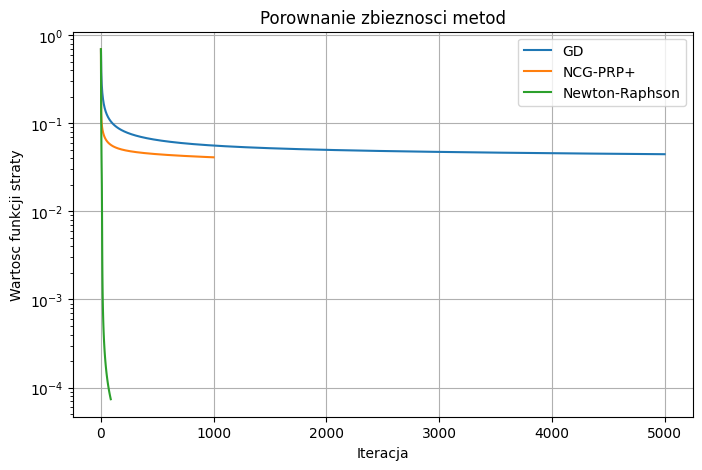

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(result_gd["loss_hist"], label="GD")
plt.plot(result_ncg["loss_hist"], label="NCG-PRP+")
plt.plot(result_newton["loss_hist"], label="Newton-Raphson")

plt.xlabel("Iteracja")
plt.ylabel("Wartosc funkcji straty")
plt.title("Porownanie zbieznosci metod")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

wykres normy gradientu

Norma gradientu informuje, jak blisko jesteśmy punktu stacjonarnego. Im mniejsza norma gradientu, tym słabszy jest kierunek dalszej poprawy funkcji celu.

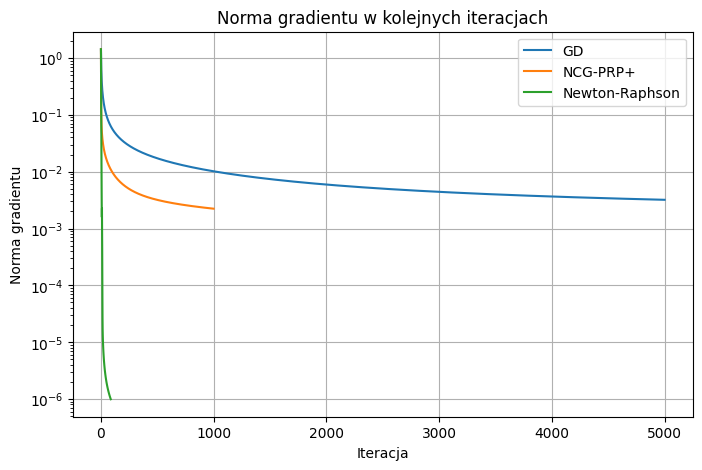

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(result_gd["grad_norm_hist"], label="GD")
plt.plot(result_ncg["grad_norm_hist"], label="NCG-PRP+")
plt.plot(result_newton["grad_norm_hist"], label="Newton-Raphson")

plt.xlabel("Iteracja")
plt.ylabel("Norma gradientu")
plt.title("Norma gradientu w kolejnych iteracjach")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

## Komentarz: NCG jako alternatywa dla Newtona

Metoda NCG-PRP+ może być traktowana jako kompromis między prostym Gradient Descent a metodą Newtona. W przeciwieństwie do Newtona nie wymaga obliczania ani przechowywania hesjanu, dlatego jest tańsza pamięciowo i łatwiejsza do zastosowania w większych problemach uczenia maszynowego.

W przeprowadzonym eksperymencie NCG-PRP+ uzyskała taką samą accuracy testową jak Gradient Descent i wyższą niż metoda Newtona, przy nieco niższej końcowej wartości funkcji straty niż GD. Oznacza to, że mimo braku informacji drugiego rzędu metoda NCG może dawać bardzo dobre wyniki klasyfikacji.

Newton-Raphson szybciej zmniejszył wartość funkcji straty i spełnił warunek stopu po mniejszej liczbie iteracji, ale wymagał użycia hesjanu. W praktyce NCG jest akceptowalną alternatywą dla metod drugiego rzędu wtedy, gdy liczba cech jest duża i liczenie lub przechowywanie hesjanu staje się kosztowne.

## Wnioski z części podstawowej

W projekcie zaimplementowano regresję logistyczną jako problem minimalizacji funkcji straty logistycznej. Dane zostały wcześniej wystandaryzowane, ponieważ metody gradientowe są wrażliwe na skalę zmiennych.

Porównano trzy metody optymalizacji:
- Gradient Descent ze stałym krokiem,
- NCG-PRP+ z backtrackingiem Armijo,
- Newton-Raphson z backtracking line search.

Gradient Descent wykonuje proste kroki w kierunku przeciwnym do gradientu, dlatego zwykle wymaga większej liczby iteracji. NCG-PRP+ wykorzystuje informację z poprzednich gradientów i tworzy kierunki sprzężone, dzięki czemu może zbiegać szybciej bez liczenia hesjanu. Metoda Newtona korzysta z hesjanu, dlatego często potrzebuje najmniej iteracji, ale pojedyncza iteracja jest bardziej kosztowna obliczeniowo.

---

# Część rozszerzona

W części rozszerzonej sprawdzamy wymagania dodatkowe dla projektu 6:
- porównanie pamięci NCG i Newtona,
- wpływ wariantu NCG na zbieżność,
- regularyzację L2,
- porównanie z `sklearn.linear_model.LogisticRegression`.

## Memory footprint NCG i Newtona

NCG jest metodą pierwszego rzędu, więc nie musi tworzyć ani przechowywać hesjanu. W praktyce oznacza to pamięć rzędu `O(n)`, bo potrzebne są głównie wektory: aktualne wagi, gradient i kierunek.

Metoda Newtona korzysta z hesjanu, czyli macierzy rozmiaru `n x n`. Dlatego jej koszt pamięciowy rośnie jak `O(n^2)`. Dla naszego zbioru liczba cech po dodaniu wyrazu wolnego jest mała, ale różnica staje się bardzo ważna przy dużych modelach.

In [21]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

# Liczba parametrów modelu logistycznego, czyli liczba kolumn po dodaniu biasu.
n_params = X_train.shape[1]

# Przybliżenie pamięci dla jednej tablicy float64: 8 bajtów na element.
bytes_float = 8

memory_rows = []
for n_demo in [n_params, 1000, 10000]:
    ncg_bytes = 3 * n_demo * bytes_float          # w, gradient, kierunek
    newton_bytes = (n_demo * n_demo + 2 * n_demo) * bytes_float  # hesjan + kilka wektorów
    memory_rows.append({
        "liczba_parametrow": n_demo,
        "NCG_O(n)_MB": ncg_bytes / 1024**2,
        "Newton_O(n2)_MB": newton_bytes / 1024**2,
        "stosunek_Newton_do_NCG": newton_bytes / ncg_bytes
    })

memory_df = pd.DataFrame(memory_rows)
memory_df

,liczba_parametrow,NCG_O(n)_MB,Newton_O(n2)_MB,stosunek_Newton_do_NCG
0,31,0.000710,0.007805,11.0
1,1000,0.022888,7.644653,334.0
2,10000,0.228882,763.092041,3334.0


Widać, że dla małego zbioru `breast_cancer` sam hesjan nie jest problemem. Jednak przy większej liczbie parametrów pamięć Newtona rośnie kwadratowo. To jest główny praktyczny argument za NCG w problemach uczenia maszynowego: metoda może być znacznie lżejsza pamięciowo, bo nie wymaga przechowywania macierzy drugich pochodnych.

## Warianty NCG: FR, PRP+ i HS

W części podstawowej użyty był wariant PRP+. Teraz porównujemy trzy warianty nieliniowej metody gradientów sprzężonych:
- FR, czyli Fletcher-Reeves,
- PRP+, czyli Polak-Ribiere z obcięciem współczynnika beta od dołu przez zero,
- HS, czyli Hestenes-Stiefel.

Wszystkie warianty korzystają z tego samego backtrackingu Armijo, żeby porównanie dotyczyło głównie sposobu wyznaczania kierunku.

In [22]:
def ncg_general(X, y, beta_type="PRP+", max_iter=1000, tol=1e-6):
    """
    Ogólna implementacja NCG dla regresji logistycznej.

    beta_type:
    - "FR"   : Fletcher-Reeves,
    - "PRP+" : Polak-Ribiere+,
    - "HS"   : Hestenes-Stiefel.

    Zastosowano restart, jeśli kierunek przestaje być kierunkiem spadku.
    """
    n = X.shape[1]
    w = np.zeros(n)

    g = logistic_gradient(w, X, y)
    d = -g

    loss_hist = []
    grad_norm_hist = []
    alpha_hist = []
    restart_iter = []

    start_time = time.time()

    for k in range(max_iter):
        loss_value = logistic_loss(w, X, y)
        grad_norm = np.linalg.norm(g)

        loss_hist.append(loss_value)
        grad_norm_hist.append(grad_norm)

        if grad_norm < tol:
            converged = True
            break

        # Jeżeli kierunek nie jest kierunkiem spadku, robimy restart do -gradientu.
        if np.dot(g, d) >= 0:
            d = -g
            restart_iter.append(k)

        alpha = armijo_backtracking(w, d, X, y, alpha0=1.0, c=1e-4, rho=0.5)
        alpha_hist.append(alpha)

        w_new = w + alpha * d
        g_new = logistic_gradient(w_new, X, y)

        if beta_type == "FR":
            denom = np.dot(g, g)
            beta = np.dot(g_new, g_new) / denom if denom > 0 else 0.0
        elif beta_type == "PRP+":
            denom = np.dot(g, g)
            beta_prp = np.dot(g_new, g_new - g) / denom if denom > 0 else 0.0
            beta = max(0.0, beta_prp)
            if beta == 0.0:
                restart_iter.append(k)
        elif beta_type == "HS":
            y_diff = g_new - g
            denom = np.dot(d, y_diff)
            beta = np.dot(g_new, y_diff) / denom if abs(denom) > 1e-14 else 0.0
            if beta < 0:
                beta = 0.0
                restart_iter.append(k)
        else:
            raise ValueError("Nieznany wariant beta_type")

        d = -g_new + beta * d
        w = w_new
        g = g_new
    else:
        converged = False

    end_time = time.time()

    return {
        "w": w,
        "iterations": len(loss_hist),
        "converged": converged,
        "time": end_time - start_time,
        "final_loss": logistic_loss(w, X, y),
        "loss_hist": loss_hist,
        "grad_norm_hist": grad_norm_hist,
        "alpha_hist": alpha_hist,
        "restart_iter": restart_iter,
        "beta_type": beta_type
    }

ncg_variant_results = {}
for beta_type in ["FR", "PRP+", "HS"]:
    ncg_variant_results[beta_type] = ncg_general(
        X_train,
        y_train,
        beta_type=beta_type,
        max_iter=1000,
        tol=1e-6
    )

variant_rows = []
for beta_type, result in ncg_variant_results.items():
    variant_rows.append({
        "wariant": beta_type,
        "iteracje": result["iterations"],
        "stop": result["converged"],
        "czas_CPU": result["time"],
        "strata_koncowa": result["final_loss"],
        "accuracy_test": accuracy(result["w"], X_test, y_test),
        "liczba_restartow": len(result["restart_iter"])
    })

variant_df = pd.DataFrame(variant_rows)
variant_df

,wariant,iteracje,stop,czas_CPU,strata_koncowa,accuracy_test,liczba_restartow
0,FR,1000,False,0.155313,0.014906,0.956140,0
1,PRP+,1000,False,0.154633,0.041097,0.982456,1000
2,HS,1000,False,0.154302,0.041097,0.982456,1000


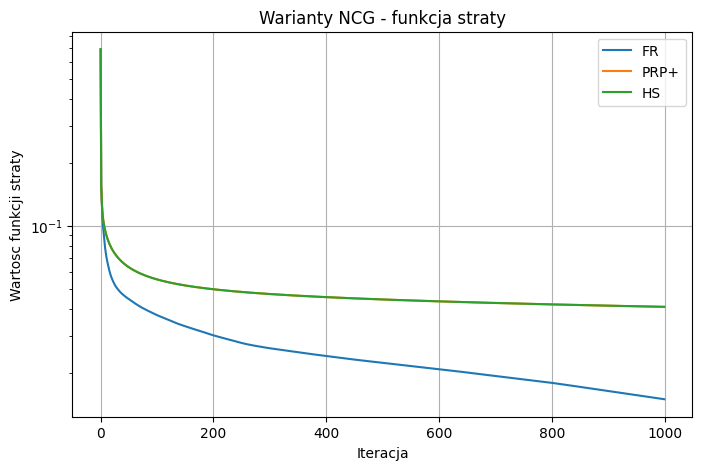

In [23]:
plt.figure(figsize=(8, 5))
for beta_type, result in ncg_variant_results.items():
    plt.plot(result["loss_hist"], label=beta_type)

plt.xlabel("Iteracja")
plt.ylabel("Wartosc funkcji straty")
plt.title("Warianty NCG - funkcja straty")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

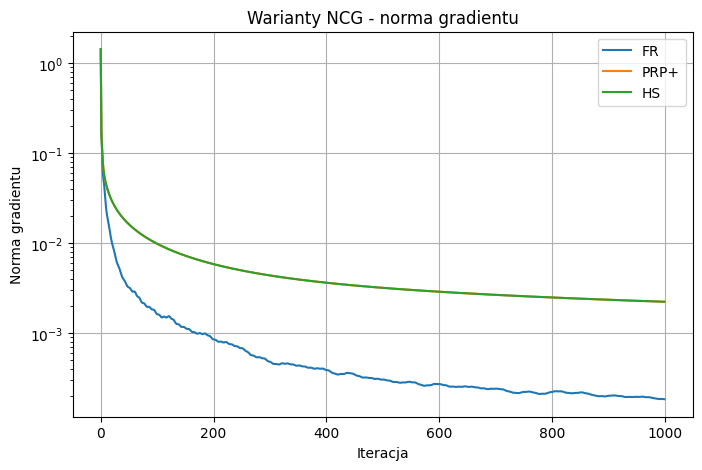

In [24]:
plt.figure(figsize=(8, 5))
for beta_type, result in ncg_variant_results.items():
    plt.plot(result["grad_norm_hist"], label=beta_type)

plt.xlabel("Iteracja")
plt.ylabel("Norma gradientu")
plt.title("Warianty NCG - norma gradientu")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()

Warianty NCG różnią się tym, jak silnie wykorzystują poprzedni kierunek. FR jest najprostszy i bywa bardziej zachowawczy. PRP+ zwykle jest stabilniejszy, bo obcięcie `beta` do wartości nieujemnych działa jak automatyczny restart. HS potrafi robić agresywniejsze kroki, ale wymaga kontroli mianownika i restartów, żeby nie utracić kierunku spadku.

## Regularyzacja L2

Regularyzacja L2 dodaje do funkcji celu karę za duże wartości wag:

`l_lambda(w) = l(w) + lambda / 2 * ||w||^2`

Regularyzacja zmniejsza wartości wag modelu, ale nie zmniejszamy pierwszej wagi, czyli wyrazu wolnego. Dzięki temu model jest prostszy i mniej podatny na przeuczenie.

In [25]:
def logistic_loss_l2(w, X, y, lambda_=0.0):
    penalty = 0.5 * lambda_ * np.sum(w[1:] ** 2)
    return logistic_loss(w, X, y) + penalty


def logistic_gradient_l2(w, X, y, lambda_=0.0):
    grad = logistic_gradient(w, X, y).copy()
    grad[1:] += lambda_ * w[1:]
    return grad


def armijo_backtracking_l2(w, d, X, y, lambda_=0.0, alpha0=1.0, c=1e-4, rho=0.5):
    alpha = alpha0
    loss_w = logistic_loss_l2(w, X, y, lambda_)
    grad = logistic_gradient_l2(w, X, y, lambda_)

    while logistic_loss_l2(w + alpha * d, X, y, lambda_) > loss_w + c * alpha * np.dot(grad, d):
        alpha *= rho
        if alpha < 1e-12:
            break

    return alpha


def ncg_prp_plus_l2(X, y, lambda_=0.0, max_iter=1000, tol=1e-6):
    """
    NCG-PRP+ dla regresji logistycznej z regularyzacją L2.
    """
    n = X.shape[1]
    w = np.zeros(n)

    g = logistic_gradient_l2(w, X, y, lambda_)
    d = -g

    loss_hist = []
    grad_norm_hist = []

    start_time = time.time()

    for k in range(max_iter):
        loss_hist.append(logistic_loss_l2(w, X, y, lambda_))
        grad_norm = np.linalg.norm(g)
        grad_norm_hist.append(grad_norm)

        if grad_norm < tol:
            converged = True
            break

        if np.dot(g, d) >= 0:
            d = -g

        alpha = armijo_backtracking_l2(w, d, X, y, lambda_=lambda_)
        w_new = w + alpha * d
        g_new = logistic_gradient_l2(w_new, X, y, lambda_)

        denom = np.dot(g, g)
        beta_prp = np.dot(g_new, g_new - g) / denom if denom > 0 else 0.0
        beta = max(0.0, beta_prp)

        d = -g_new + beta * d
        w = w_new
        g = g_new
    else:
        converged = False

    end_time = time.time()

    return {
        "w": w,
        "iterations": len(loss_hist),
        "converged": converged,
        "time": end_time - start_time,
        "final_loss_reg": logistic_loss_l2(w, X, y, lambda_),
        "final_loss_plain": logistic_loss(w, X, y),
        "loss_hist": loss_hist,
        "grad_norm_hist": grad_norm_hist,
        "lambda": lambda_
    }

lambda_values = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
l2_results = {}

for lambda_ in lambda_values:
    l2_results[lambda_] = ncg_prp_plus_l2(
        X_train,
        y_train,
        lambda_=lambda_,
        max_iter=1000,
        tol=1e-6
    )

l2_rows = []
for lambda_, result in l2_results.items():
    l2_rows.append({
        "lambda": lambda_,
        "iteracje": result["iterations"],
        "stop": result["converged"],
        "strata_bez_kary": result["final_loss_plain"],
        "strata_z_kara": result["final_loss_reg"],
        "accuracy_test": accuracy(result["w"], X_test, y_test),
        "norma_wag_bez_biasu": np.linalg.norm(result["w"][1:])
    })

l2_df = pd.DataFrame(l2_rows)
l2_df

,lambda,iteracje,stop,strata_bez_kary,strata_z_kara,accuracy_test,norma_wag_bez_biasu
0,0.0000,1000,False,0.041097,0.041097,0.982456,5.976103
1,0.0001,1000,False,0.041592,0.043242,0.982456,5.744882
2,0.0010,1000,False,0.046139,0.055888,0.982456,4.415616
3,0.0100,745,True,0.069100,0.096556,0.964912,2.343354
4,0.1000,164,True,0.134006,0.194993,0.964912,1.104420
5,1.0000,49,True,0.284727,0.382504,0.912281,0.442215


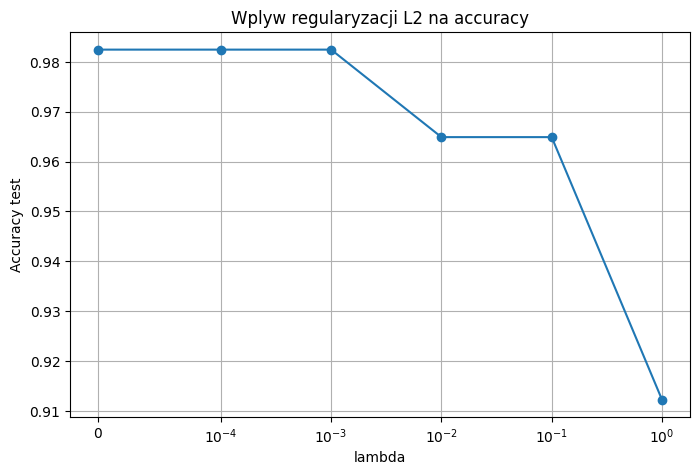

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(l2_df["lambda"], l2_df["accuracy_test"], marker="o")
plt.xscale("symlog", linthresh=1e-4)
plt.xlabel("lambda")
plt.ylabel("Accuracy test")
plt.title("Wplyw regularyzacji L2 na accuracy")
plt.grid(True)
plt.show()

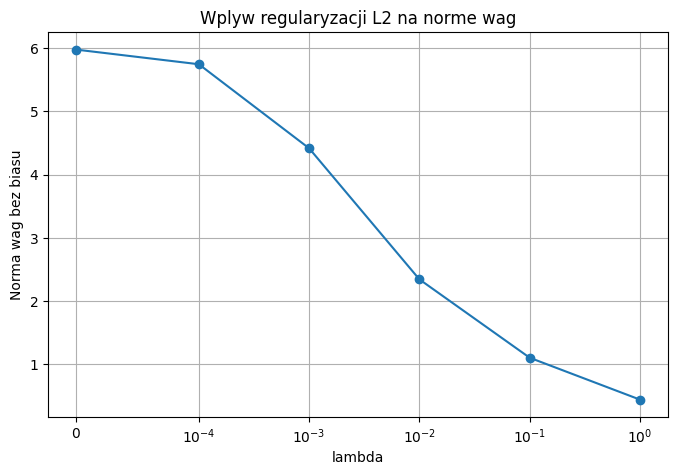

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(l2_df["lambda"], l2_df["norma_wag_bez_biasu"], marker="o")
plt.xscale("symlog", linthresh=1e-4)
plt.xlabel("lambda")
plt.ylabel("Norma wag bez biasu")
plt.title("Wplyw regularyzacji L2 na norme wag")
plt.grid(True)
plt.show()

Po dodaniu L2 norma wag spada, szczególnie dla większych wartości `lambda`. To jest oczekiwane, ponieważ kara L2 ogranicza zbyt duże współczynniki modelu. Accuracy nie musi rosnąć monotonicznie, bo zbyt duża regularyzacja może prowadzić do niedouczenia modelu.

## Porównanie z LogisticRegression ze sklearn

Na koniec porównujemy własną implementację z biblioteką referencyjną. Używamy `sklearn.linear_model.LogisticRegression`, czyli gotowej implementacji regresji logistycznej. To sprawdza, czy własne metody osiągają porównywalną jakość klasyfikacji.

In [28]:
# sklearn pracuje na etykietach {0, 1}, więc zamieniamy {-1, 1} z powrotem na {0, 1}.
y_train_sklearn = (y_train == 1).astype(int)
y_test_sklearn = (y_test == 1).astype(int)

# Usuwamy kolumne biasu, bo sklearn dodaje intercept samodzielnie.
X_train_sklearn = X_train[:, 1:]
X_test_sklearn = X_test[:, 1:]

sk_model = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    max_iter=10000,
    random_state=0
)
sk_model.fit(X_train_sklearn, y_train_sklearn)

sk_train_acc = sk_model.score(X_train_sklearn, y_train_sklearn)
sk_test_acc = sk_model.score(X_test_sklearn, y_test_sklearn)

reference_rows = [
    {
        "metoda": "wlasne GD",
        "accuracy_test": accuracy(result_gd["w"], X_test, y_test),
        "strata_treningowa": logistic_loss(result_gd["w"], X_train, y_train)
    },
    {
        "metoda": "wlasne NCG-PRP+",
        "accuracy_test": accuracy(result_ncg["w"], X_test, y_test),
        "strata_treningowa": logistic_loss(result_ncg["w"], X_train, y_train)
    },
    {
        "metoda": "wlasny Newton-Raphson",
        "accuracy_test": accuracy(result_newton["w"], X_test, y_test),
        "strata_treningowa": logistic_loss(result_newton["w"], X_train, y_train)
    },
    {
        "metoda": "sklearn LogisticRegression",
        "accuracy_test": sk_test_acc,
        "strata_treningowa": np.nan
    }
]

reference_df = pd.DataFrame(reference_rows)
reference_df

,metoda,accuracy_test,strata_treningowa
0,wlasne GD,0.982456,0.044568
1,wlasne NCG-PRP+,0.982456,0.041097
2,wlasny Newton-Raphson,0.947368,0.000074
3,sklearn LogisticRegression,0.982456,NaN


Wynik ze `sklearn` jest punktem odniesienia, a nie idealnie takim samym eksperymentem, ponieważ biblioteka domyślnie stosuje regularyzację L2 i ma własne kryteria stopu. Mimo tego accuracy jest porównywalne z wynikami własnych metod, co potwierdza, że pipeline regresji logistycznej został zaimplementowany poprawnie.

## Wnioski z części rozszerzonej

Część rozszerzona pokazuje, że NCG jest dobrą alternatywą między prostym Gradient Descent a metodą Newtona. W porównaniu z GD metoda NCG wykorzystuje informację z poprzednich iteracji, więc zwykle potrafi szybciej poprawiać kierunek poszukiwań. W porównaniu z Newtonem nie wymaga hesjanu, dlatego ma znacznie mniejszy koszt pamięciowy.

Warianty NCG dają zbliżone wyniki klasyfikacji, ale różnią się stabilnością. PRP+ jest praktycznie wygodny, ponieważ mechanizm `max(0, beta)` działa jak restart i zmniejsza ryzyko złych kierunków. Regularyzacja L2 zmniejsza normę wag i pomaga kontrolować dopasowanie modelu. Porównanie ze `sklearn.linear_model.LogisticRegression` potwierdza, że własna implementacja daje wyniki zgodne z biblioteką referencyjną.